In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()

,text,label
0,grow b 1965 watch love thunderbird mate school...,0
1,movie dvd player sit coke chip expectation hop...,0
2,people know particular time past like feel nee...,0
3,great interest biblical movie bore death minut...,0
4,m die hard dad army fan change get tape dvd au...,1


In [2]:
#splitting in x and y:
X = df["text"]
y = df["label"]

In [5]:
#train test split:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Text Vectorization:**

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)   
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

**Model Training:**

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**Prediction:**

In [13]:
y_pred = model.predict(X_test_vec)

**Evaluation:**

In [15]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.887125
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      3966
           1       0.88      0.90      0.89      4034

    accuracy                           0.89      8000
   macro avg       0.89      0.89      0.89      8000
weighted avg       0.89      0.89      0.89      8000



**Confusion Matrix:**

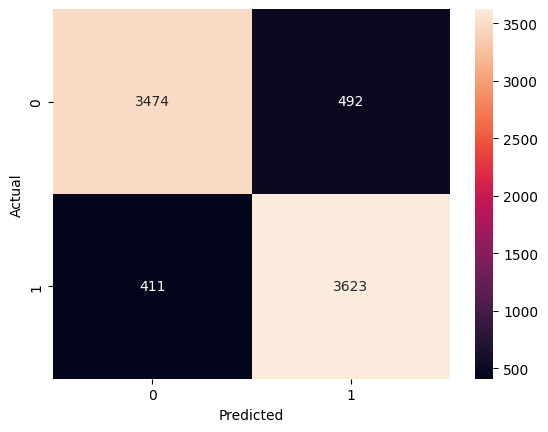

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Comparison Model:**

In [17]:
# Naive Bayes Model

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test_vec)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.859
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      3966
           1       0.85      0.87      0.86      4034

    accuracy                           0.86      8000
   macro avg       0.86      0.86      0.86      8000
weighted avg       0.86      0.86      0.86      8000



**Confusion Matrix:**

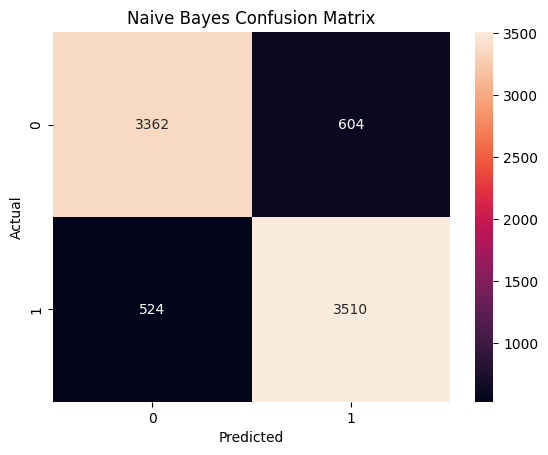

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

**Saving Files:**

In [21]:
import pickle
with open("../models/model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../models/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)